# 02 · Tìm ra vấn đề: khách hàng bị mất ở bước thanh toán

**Câu hỏi kinh doanh:** công ty đang chi tiền khuyến mãi để kéo khách mới — vậy có bao nhiêu khách đã muốn mua nhưng **không mua được**, và mất ở đâu?

Quy trình: đặt giả thuyết → kiểm tra → bác bỏ / điều chỉnh → định lượng tác động → xác định ai chịu trách nhiệm.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # để import được thư mục src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
BLUE, RED, GREY = "#2f6db5", "#d1495b", "#9aa5b1"

In [2]:
from src.data_prep import load_tickets
from src import metrics

df = load_tickets()
first = metrics.first_attempts(df)

## 1. Giả thuyết ban đầu: "khách bị lỗi thanh toán lần đầu thì ít quay lại hơn"
So sánh: khách lỗi lần đầu có giao dịch thành công sau đó không, với khách thành công lần đầu có mua tiếp không.

In [3]:
failed_first = first[first["first_failed"]]
ok_first = first[~first["first_failed"]]
later_success = df[df["is_success"]].groupby("customer_id").size()
print(f"Khách lỗi lần đầu, sau đó có mua thành công: {failed_first['ever_converted'].mean():.1%}")
print(f"Khách thành công lần đầu, sau đó mua thêm: {(ok_first.index.map(later_success) > 1).mean():.1%}")

Khách lỗi lần đầu, sau đó có mua thành công: 18.5%
Khách thành công lần đầu, sau đó mua thêm: 16.7%


**Giả thuyết không được ủng hộ** — và hai con số trên thật ra đo hai thứ khác nhau (với nhóm lỗi, "mua thành công sau đó" phần lớn là *thử lại ngay*, chưa phải "quay lại"). Câu hỏi đúng hơn là: **khách lỗi lần đầu có bao giờ trở thành khách hàng không?**

## 2. Phễu: từ lần thanh toán đầu tiên đến khách bị mất

Lỗi lần đầu: 14.1% tổng khách
Không bao giờ mua được: 81.5% số khách lỗi lần đầu
Thử lại thành công trong 1 giờ: 899 | trong 24 giờ: 1,015


Tỷ lệ MỌI giao dịch lỗi được mua lại trong 7 ngày: 7.1%


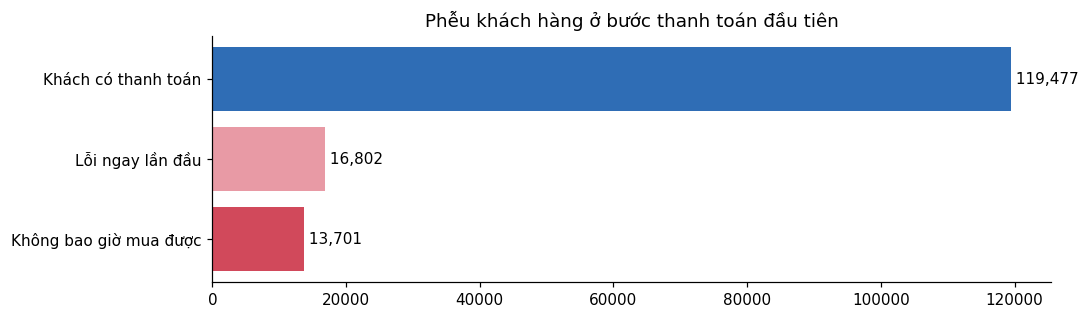

In [4]:
s = metrics.lost_at_payment_summary(df)
funnel = pd.Series({
    "Khách có thanh toán": s["customers_total"],
    "Lỗi ngay lần đầu": s["failed_first_attempt"],
    "Không bao giờ mua được": s["never_converted"],
})
fig, ax = plt.subplots(figsize=(10, 3))
ax.barh(funnel.index[::-1], funnel.values[::-1], color=[RED, "#e89aa5", BLUE])
for i, v in enumerate(funnel.values[::-1]):
    ax.text(v, i, f" {v:,}", va="center")
ax.set_title("Phễu khách hàng ở bước thanh toán đầu tiên")
plt.tight_layout()
print(f"Lỗi lần đầu: {s['failed_first_attempt_pct']:.1%} tổng khách")
print(f"Không bao giờ mua được: {s['never_converted_pct_of_failed']:.1%} số khách lỗi lần đầu")
print(f"Thử lại thành công trong 1 giờ: {s['recovered_within_1h']:,} | trong 24 giờ: {s['recovered_within_24h']:,}")
print(f"Tỷ lệ MỌI giao dịch lỗi được mua lại trong 7 ngày: {metrics.recovery_rate(df, 7):.1%}")

> 🔴 **16,802 khách (14.1%) lỗi thanh toán ngay lần đầu, và 13,701 người (81.5%) trong số đó không bao giờ mua được vé.**
> Chỉ khoảng 1,000 khách tự thử lại thành công trong 24 giờ; tính trên mọi giao dịch lỗi, chỉ **7.1%** được mua lại trong 7 ngày.

Hiện **không có quy trình nào liên hệ lại** những khách này — họ đến (thường nhờ khuyến mãi), gặp lỗi và rời đi.

## 3. Khách bị mất vì lỗi gì, qua phương thức nào, khi nào?

error_group
external    0.736
customer    0.251
internal    0.013
Name: proportion, dtype: float64

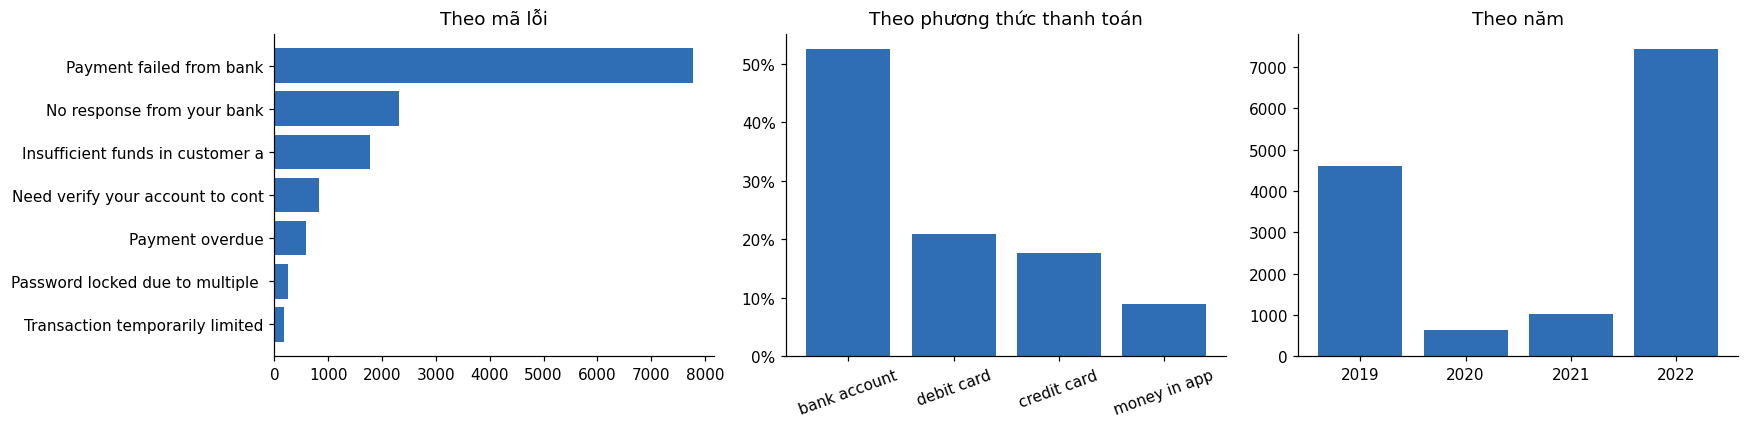

In [5]:
lost = first[first["first_failed"] & ~first["ever_converted"]]
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
by_error = lost["description"].str.slice(0, 32).value_counts()
ax[0].barh(by_error.index[::-1], by_error.values[::-1], color=BLUE); ax[0].set_title("Theo mã lỗi")
by_method = lost["paying_method"].value_counts(normalize=True)
ax[1].bar(by_method.index, by_method, color=BLUE); ax[1].set_title("Theo phương thức thanh toán")
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(1)); ax[1].tick_params(axis="x", rotation=20)
by_year = lost["year"].value_counts().sort_index()
ax[2].bar(by_year.index.astype(str), by_year, color=BLUE); ax[2].set_title("Theo năm")
plt.tight_layout()
lost["error_group"].value_counts(normalize=True).round(3)

- **2 mã lỗi phía ngân hàng** (*Payment failed from bank* 7,775 + *No response from your bank* 2,312) gây mất ~74% số khách này → khách **không tự sửa được**.
- **52.5% khách bị mất dùng bank account**; chỉ 8.9% dùng ví trong app.
- 2022 là năm mất nhiều nhất (7,436 khách) — trùng với đợt lỗi ngân hàng tăng vọt và giai đoạn chạy khuyến mãi mạnh.

## 4. Định lượng tác động
> Đơn vị tiền theo đúng cột `final_price` của dataset. Các kịch bản dưới đây là **ước tính**, không phải kết quả đã xảy ra.

In [6]:
value_lost = s["lost_first_order_value"]
scenarios = pd.DataFrame({"tỷ lệ cứu được": [0.10, 0.20, 0.30]})
scenarios["khách cứu được"] = (scenarios["tỷ lệ cứu được"] * s["never_converted"]).round().astype(int)
scenarios["giá trị đơn đầu cứu được"] = (scenarios["tỷ lệ cứu được"] * value_lost).round()
print(f"Giá trị đơn đầu tiên của 13,701 khách bị mất: {value_lost:,.0f}")
print(f"Giá vé thành công trung bình: {s['avg_success_ticket_value']:.2f}")
scenarios.style.format({"tỷ lệ cứu được": "{:.0%}", "giá trị đơn đầu cứu được": "{:,.0f}"})

Giá trị đơn đầu tiên của 13,701 khách bị mất: 107,301
Giá vé thành công trung bình: 7.72


,tỷ lệ cứu được,khách cứu được,giá trị đơn đầu cứu được
0,10%,1370,"10,730"
1,20%,2740,"21,460"
2,30%,4110,"32,190"


Con số trên **chỉ tính đơn đầu tiên** — chưa tính chi phí khuyến mãi/quảng cáo đã bỏ ra để kéo khách đó vào, và các lần mua sau nếu khách ở lại. Vì vậy đây là **cận dưới** của thiệt hại.

## 5. Ai chịu ảnh hưởng — vấn đề xuyên phòng ban

| Phòng ban | Họ đang thấy gì | Thực chất |
|---|---|---|
| **Marketing** | Chi khuyến mãi, khách mới tăng nhưng giữ chân kém | Một phần khách mới **chưa bao giờ mua được** vì lỗi thanh toán |
| **CSKH** | Nhận phàn nàn rời rạc | Không có danh sách khách lỗi để chủ động liên hệ lại |
| **Product / IT** | Lỗi ngân hàng "không phải lỗi của mình" | 3/4 khách bị mất là do lỗi external; ví trong app lỗi chỉ 2.6% |
| **Tài chính** | Doanh thu thấp hơn kỳ vọng | Đơn lỗi không được cứu = doanh thu mất ngay ở bước cuối |

## 6. Từ vấn đề → giải pháp (các notebook tiếp theo)
1. **Phòng ngừa** (notebook 03): model dự đoán giao dịch có rủi ro lỗi cao → gợi ý phương thức an toàn hơn trước khi thanh toán.
2. **Phát hiện sớm** (notebook 04): cảnh báo khi tỷ lệ lỗi một nhóm tăng bất thường trong tuần.
3. **Cứu đơn tự động** (notebook 04): danh sách khách lỗi + tin nhắn theo mã lỗi gửi cho CSKH mỗi tuần.
4. **Bản tin & dữ liệu cho từng phòng ban** (notebook 04–05): LLM viết bản tin từ số liệu đã tính sẵn, có kiểm tra chống bịa số.